In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# Add the modules/ folder to the Python path
module_path = os.path.abspath(os.path.join('..', 'modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

from imports import *


2025-06-05 11:31:10,070 - INFO - Common imports loading...


Executing common imports from imports.py...


In [2]:
cosmotable = np.loadtxt('../data/CosmoTable.dat')
cosmotable_om = cosmotable[:,1]
cosmotable_h = cosmotable[:,2]
cosmotable_w0 = cosmotable[:,3]
cosmotable_sig8 =  cosmotable[:,4]
cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    [cosmotable_oc.min(), cosmotable_oc.max()]
])

print(param_bounds)


lh_df = pd.DataFrame(cosmotable[:,1:], columns=["Om", "h", "w0", "sig8", "Oc"])
# lh_df

[[ 0.1019  0.5482]
 [ 0.6034  0.8129]
 [-1.9866 -0.5223]
 [ 0.4716  1.3428]
 [ 0.0546  0.5009]]


In [3]:
theta1_arcmin = 15.0  # Use a descriptive name
R_pixels = int(theta1_arcmin / 0.5) #0.5 arcmin/pixel resolution
print(f"Filter radius in pixels: {R_pixels}")

filter_type = 'tophat'
cosmoindex = 0
tomobin=5

edges = np.linspace(-0.06, 0.06, 102)
centers = (edges[1:] + edges[:-1]) / 2
snr = np.linspace(-9, 9, 101) # Define SNR range for output interpolation
sim_l1_runs, sim_pdf_runs, avg_sim_l1, std_sim_l1, avg_sim_pdf, std_sim_pdf, sim_ell_bins, sim_cls_runs = get_simulation_l1(cosmoindex, tomobin,edges, centers,snr,R_pixels=R_pixels, filter_type=filter_type)

# Calculate moments from average simulation PDF
sim_stats = get_moments(centers, avg_sim_pdf)
sim_mean, sim_var, sim_skew, sim_kurt, sim_norm = sim_stats
print(f"Simulation Avg PDF Moments: Mean={sim_mean:.4g}, Variance={sim_var:.4g}, Skewness={sim_skew:.4g}, Kurtosis={sim_kurt:.4g}, Norm={sim_norm:.4g}")



Filter radius in pixels: 30


2025-06-05 11:31:10,676 - INFO - Unable to initialize backend 'cuda': FAILED_PRECONDITION: No visible GPU devices.
2025-06-05 11:31:10,676 - INFO - Unable to initialize backend 'rocm': NOT_FOUND: Could not find registered platform with name: "rocm". Available platform names are: Interpreter CUDA
2025-06-05 11:31:10,677 - INFO - Unable to initialize backend 'tpu': module 'jaxlib.xla_extension' has no attribute 'get_tpu_client'
2025-06-05 11:31:10,677 - WARNING - No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
the ell_bins shape:  (100,) and : 14.95
Simulation Avg PDF Moments: Mean=-1.356e-07, Variance=1.182e-05, Skewness=-58.26, Kurtosis=0.2198, Norm=1


--- Running for Cosmology Index: 0 ---
 
--- Running Cosmology Setup ---
Cosmological Parameters:
  h=0.6766, Om=0.3282, Oc=0.2809, Ob=0.0473, sigma8=0.6677, w0=-1.2376, wa=0.0000
Initializing Cosmology...
the min and max values of k are:  1e-05 1.5848931924611136 and length is:  20
Calculating lensing geometry...
  Source Redshift: 1.1852, Comoving Distance: 2667.14 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variability is ON
Effective volume = 4.71e+07 (Mpc/h)^3
halo model calculator initialized
Variance module initialized...final z: 0.30
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.1852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 1.439651668359665e-05
run: 1 of 10
Recalibration Value Set To: 1.0
Finding critical points...
Setting ngrid = 30. Increase this for more accuracy, bu

/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:6: RuntimeWarning: invalid value encountered in power
  return nu * (1.0 - rho ** (-1.0 / nu))
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:18: RuntimeWarning: invalid value encountered in sqrt
  R1=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:24: RuntimeWarning: invalid value encountered in sqrt
  R1=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:25: RuntimeWarning: invalid value encountered in sqrt
  R2=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,


the coeffs are [-1.10755308e-06  5.26086189e-06 -5.23980854e-06 -6.22323718e-06
  4.27677981e-05 -1.13104433e-04  4.09635914e-03  3.48553391e-08]
1.678015822744383e-05
Theoretical Map Variance (sigmasq_map): 1.68e-05
Calculating predicted L1 norm...
     Metric Prediction PDF Simulation Avg PDF
0      Mean      9.744e-08         -1.356e-07
1  Variance      1.678e-05          1.182e-05
2  Skewness          -40.1             -58.26
3  Kurtosis         0.2994             0.2198
4      Norm              1                  1
 
--- Running Cosmology Setup ---
Cosmological Parameters:
  h=0.6766, Om=0.3282, Oc=0.2809, Ob=0.0473, sigma8=0.6677, w0=-1.2376, wa=0.0000
Initializing Cosmology...
the min and max values of k are:  1e-05 1.5848931924611136 and length is:  20
Calculating lensing geometry...
  Source Redshift: 1.1852, Comoving Distance: 2667.14 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variability is ON
Effective volume = 4.71e+07 (Mpc/h)^3
halo model calcul

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/scipy/interpolate/_fitpack_impl.py:724: RuntimeWarning: The number of zeros exceeds mest
  warnings.warn(RuntimeWarning("The number of zeros exceeds mest"))


The approximate critical points at redshift z:  0.2963  are:  [  882.48139773    52.30637573     7.16257948   -51.79700533
  -150.289036    -187.53041261  -201.28517009  -379.78973462
 -1403.7611564  -1460.56671952]
Smallest positive value: 52.30637573423094
Largest negative value: -246.77308671139934
Smallest distance pair of critical points: 52.30637573423094 -246.77308671139934
the coeffs are [-2.05206651e-08  1.29597443e-07  4.41092862e-07 -7.84000241e-07
  1.16251680e-05 -6.05868430e-05  2.73785715e-03 -7.43688689e-11]
7.495861772003856e-06
Theoretical Map Variance (sigmasq_map): 7.496e-06
Calculating predicted L1 norm...
     Metric Prediction PDF Simulation Avg PDF
0      Mean     -3.993e-09         -1.356e-07
1  Variance      7.496e-06          1.182e-05
2  Skewness          -48.6             -58.26
3  Kurtosis         0.1215             0.2198
4      Norm              1                  1
 
--- Running Cosmology Setup ---
Cosmological Parameters:
  h=0.6766, Om=0.3282, Oc=0.28

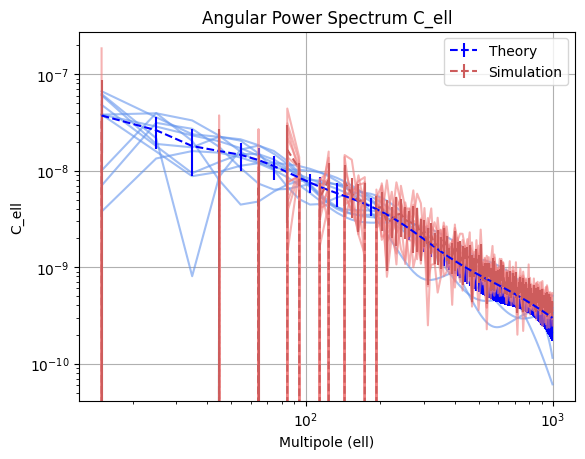

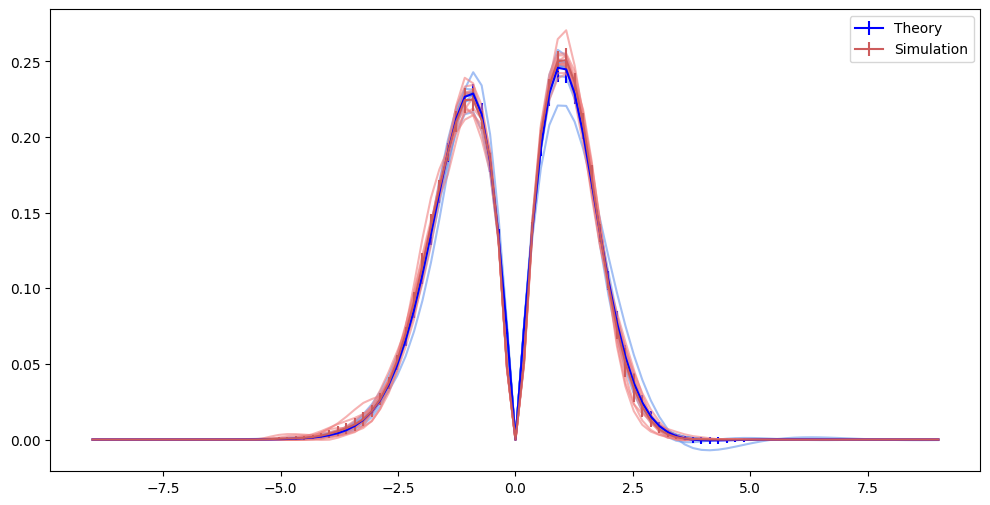

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


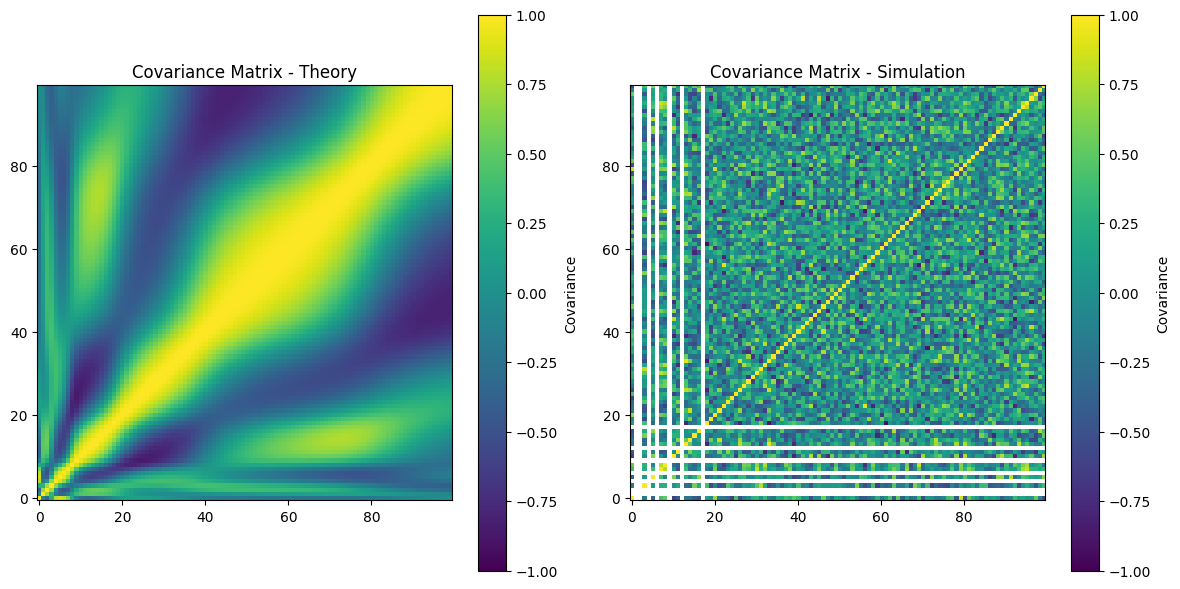

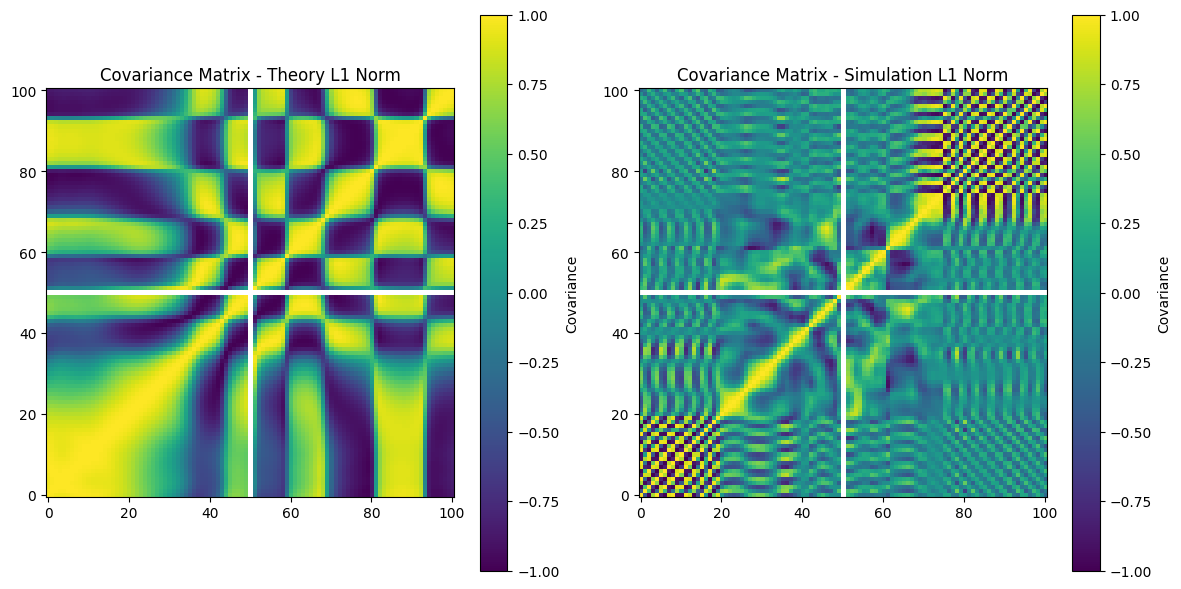

In [11]:
# Source redshift - can be single value or list depending on analysis needs
zs_source = 1.1852 #1.852 #1.134 # For this specific loop structure

# Path to n(z) file for the relevant bin
nz_file = f"../data/nz_arrays_bin{tomobin}.npy" 

if tomobin == 5:
    zs_source = 1.1852 
elif tomobin == 4:
    zs_source = 1.134

# Parameters for calculations
kmin_pk = -5 # kmin for power spectrum calculation
kmax_pk = 0.2  # kmax for power spectrum calculation 
n_lensing_planes = 7 # Number of lensing planes

# --- Simulation Volume (Optional) ---
# Set to a float value in (Mpc/h)^3 if cosmic variance noise is desired in P(k)
variability = True
if variability:
    num_realisations = 10 # Number of realizations for cosmic variance noise
else:
    num_realisations = 1
    
filter_type = 'tophat'

for cosmo_index_to_run in [cosmoindex]:
    print(f"--- Running for Cosmology Index: {cosmo_index_to_run} ---")
    print(" ")
    
    cosmology_params = {
    'h': lh_df['h'][cosmo_index_to_run],
    'Oc': lh_df['Oc'][cosmo_index_to_run],
    'Om': lh_df['Om'][cosmo_index_to_run],
    'sig8': lh_df['sig8'][cosmo_index_to_run],
    'w0': lh_df['w0'][cosmo_index_to_run],
    'wa': 0.0,  # Assuming fixed
    'ns': 0.963,
    'mnu': 0.0
    }
    
    pdf_theory_list = []
    l1_theory_list = []
    sigmasq_map_theory_list = []
    cls_theory_list = []
    for times in range(num_realisations):
        variables = setup_cosmology_and_variance(cosmology_params, zs_source, kmin_pk, kmax_pk,
                                  nz_file, n_lensing_planes, filter_type, variability,
                                  theta1_arcmin)
        
        cls_theory_list.append(variables.variance.cls)
        
        if variability:
            print(f"run: {times+1} of {num_realisations}")
            
        print(f"Recalibration Value Set To: {variables.recal_value}")
        
        smallest_positive, largest_negative = find_critical_points_for_cosmo(variables, ngrid_critical=30)
        # Set lambda range
        if smallest_positive and largest_negative is not None:
            variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)
        else:
            variables.lambdas = np.linspace(-200, 200, 20)
            print("  Warning: Using fallback lambda range.") 
            
        computed_PDF = computePDF(variables, plot_scgf=False) # Pass the updated variables object
        pdf_values, kappa_values = computed_PDF.pdf_values, computed_PDF.kappa_values
        print(f"Theoretical Map Variance (sigmasq_map): {variables.sigmasq_map:.4g}")
        
        # Calculate Predicted L1 norm
        print("Calculating predicted L1 norm...")
        l1_pred_values = get_l1_from_pdf(pdf_values, kappa_values)
        
        theory_snr = kappa_values / np.sqrt(variables.sigmasq_map)
        pdf_theory_spline = CubicSpline(theory_snr, pdf_values, extrapolate=False)
        l1_theory_spline = CubicSpline(theory_snr, l1_pred_values, extrapolate=False)
        
        pdf_theory = pdf_theory_spline(snr)
        l1_theory = l1_theory_spline(snr)
        pdf_theory_list.append(pdf_theory)
        l1_theory_list.append(l1_theory)
        sigmasq_map_theory_list.append(variables.sigmasq_map)
        
        #print theory stats
        theory_stats = get_moments(kappa_values, pdf_values)
        theory_mean, theory_var, theory_skew, theory_kurt, theory_norm = theory_stats
        comparison_data = {
            "Metric": ["Mean", "Variance", "Skewness", "Kurtosis", "Norm"],
            "Prediction PDF": [f"{v:.4g}" for v in theory_stats],
            "Simulation Avg PDF": [f"{v:.4g}" for v in sim_stats],
        }
        df_comp = pd.DataFrame(comparison_data)
        print(df_comp)
        print(" ")
        
    # Convert lists to numpy arrays
    pdf_theory_runs = np.array(pdf_theory_list)
    l1_theory_runs = np.array(l1_theory_list)
    sigmasq_map_theory_runs = np.array(sigmasq_map_theory_list)
    pdf_theory_avg = np.nanmean(pdf_theory_runs, axis=0)
    l1_theory_avg = np.nanmean(l1_theory_runs, axis=0)
    l1_theory_std = np.nanstd(l1_theory_runs, axis=0)
    
    #plotting
    
    plt.figure()
    plt.plot(variables.variance.ell, np.array(cls_theory_list).T, c='cornflowerblue', alpha=0.6)
    plt.errorbar(variables.variance.ell, np.nanmean(cls_theory_list, axis=0), yerr=np.nanstd(cls_theory_list, axis=0), label="Theory", linestyle='--', c='blue')
    plt.plot(sim_ell_bins, sim_cls_runs.T, c='lightcoral', alpha=0.6)
    plt.errorbar(sim_ell_bins, np.mean(sim_cls_runs,axis=0), yerr=np.std(sim_cls_runs,axis=0), label="Simulation", linestyle='--',c='indianred')
    plt.legend()
    plt.xlabel("Multipole (ell)")
    plt.ylabel("C_ell")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Angular Power Spectrum C_ell")
    plt.grid()
    plt.show()
        
    plt.figure(figsize=(12, 6))
    # plt.subplot(1, 2, 1)
    plt.plot(snr, l1_theory_runs.T, c='cornflowerblue', alpha=0.6)
    plt.errorbar(snr, l1_theory_avg, yerr = l1_theory_std, c='blue', label='Theory')
    plt.plot(snr, sim_l1_runs.T, c='lightcoral',alpha=0.6)
    plt.errorbar(snr, avg_sim_l1, yerr = np.std(sim_l1_runs, axis=0), c='indianred', label="Simulation")
    plt.legend()
    plt.show()



cls_cov_theory = np.corrcoef(np.array(cls_theory_list).T)
cls_cov_sim = np.corrcoef(sim_cls_runs.T)

plt.figure(figsize=(12, 6))
vmin = -1
vmax = 1
plt.subplot(1, 2, 1)
plt.imshow(cls_cov_theory, cmap='viridis', interpolation='nearest', origin='lower',vmin=vmin, vmax=vmax)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix - Theory')
plt.subplot(1, 2, 2)
plt.imshow(cls_cov_sim, cmap='viridis', interpolation='nearest', origin='lower',vmin=vmin, vmax=vmax)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix - Simulation')
plt.tight_layout()
plt.show()

l1_cov_theory = np.corrcoef(l1_theory_runs.T)
l1_cov_sim = np.corrcoef(sim_l1_runs.T)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(l1_cov_theory, cmap='viridis', interpolation='nearest', origin='lower', vmin=-1, vmax=1)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix - Theory L1 Norm')
plt.subplot(1, 2, 2)
plt.imshow(l1_cov_sim, cmap='viridis', interpolation='nearest', origin='lower', vmin=-1, vmax=1)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix - Simulation L1 Norm')
plt.tight_layout()
plt.show()

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


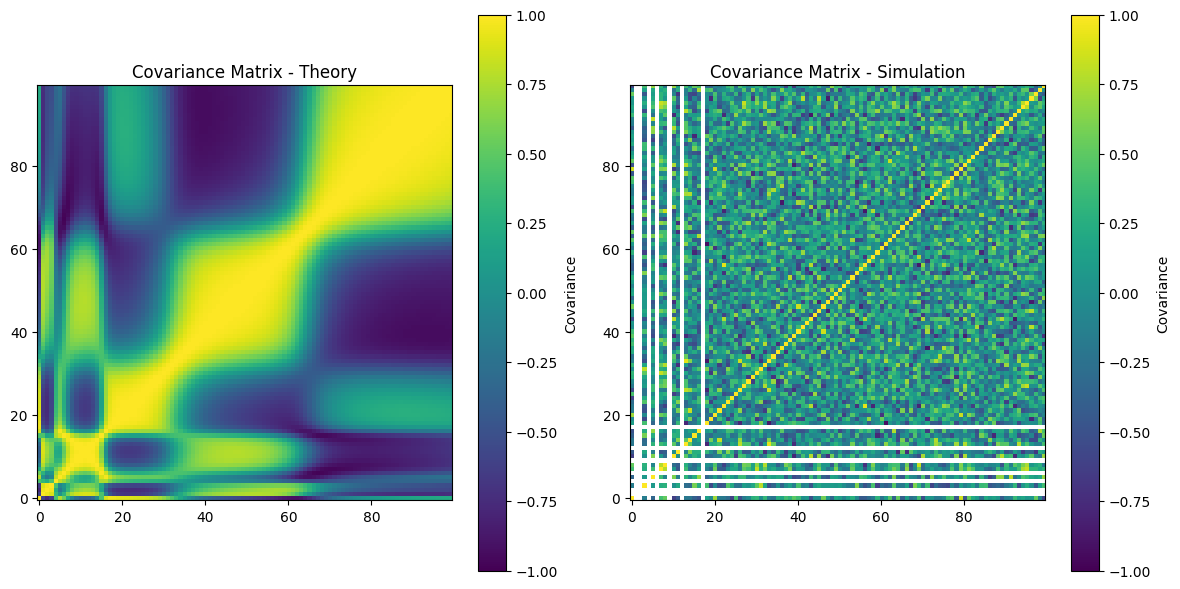

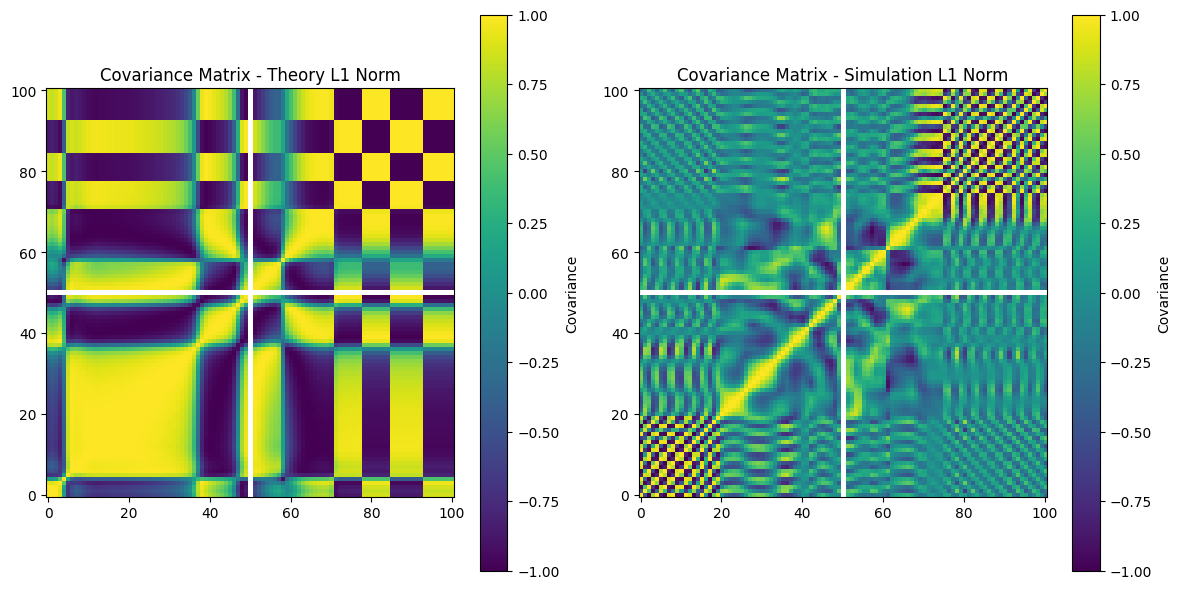